In [1]:
# ==========================================================
# CELL 1: IMPORT LIBRARIES

# Import required libraries
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore unnecessary warnings
warnings.filterwarnings("ignore")

# Configure plotting style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Configure pandas display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 150)

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("=" * 70)
print("Libraries Imported Successfully")
print("=" * 70)

Libraries Imported Successfully


In [2]:
# ==========================================================
# CELL 2: LOAD DATASET

from pathlib import Path
import pandas as pd

dataset_path = Path(
    r"C:\Users\bts\OneDrive\Desktop\Auspify\Dataset\Dataset.csv"
)

try:
    df = pd.read_csv(dataset_path)

    print("=" * 70)
    print("Dataset Loaded Successfully")
    print("=" * 70)

    print(f"Dataset Shape : {df.shape}")

    display(df.head())
    display(df.tail())

except Exception as e:
    print(e)

Dataset Loaded Successfully
Dataset Shape : (8790, 10)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
8785,s8797,TV Show,Yunus Emre,Not Given,Turkey,1/17/2017,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas"
8786,s8798,TV Show,Zak Storm,Not Given,United States,9/13/2018,2016,TV-Y7,3 Seasons,Kids' TV
8787,s8801,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,12/15/2016,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ..."
8788,s8784,TV Show,Yoko,Not Given,Pakistan,6/23/2018,2016,TV-Y,1 Season,Kids' TV
8789,s8786,TV Show,YOM,Not Given,Pakistan,6/7/2018,2016,TV-Y7,1 Season,Kids' TV


In [3]:
# ==========================================================
# CELL 3: INITIAL DATA EXPLORATION

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

df.info()

print("\n" + "=" * 70)
print("NUMERICAL SUMMARY")
print("=" * 70)

display(df.describe())

print("\n" + "=" * 70)
print("COMPLETE SUMMARY")
print("=" * 70)

display(df.describe(include="all"))

print("\n" + "=" * 70)
print("COLUMN NAMES")
print("=" * 70)

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)

display(df.dtypes)

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().mean() * 100).round(2)
})

display(missing_df.sort_values("Missing Values", ascending=False))

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8790 non-null   str  
 1   type          8790 non-null   str  
 2   title         8790 non-null   str  
 3   director      8790 non-null   str  
 4   country       8790 non-null   str  
 5   date_added    8790 non-null   str  
 6   release_year  8790 non-null   int64
 7   rating        8790 non-null   str  
 8   duration      8790 non-null   str  
 9   listed_in     8790 non-null   str  
dtypes: int64(1), str(9)
memory usage: 1.6 MB

NUMERICAL SUMMARY


,release_year
count,8790.000000
mean,2014.183163
std,8.825466
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000



COMPLETE SUMMARY


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
count,8790,8790,8790,8790,8790,8790,8790.000000,8790,8790,8790
unique,8790,2,8787,4528,86,1713,NaN,14,220,513
top,s1,Movie,9-Feb,Not Given,United States,1/1/2020,NaN,TV-MA,1 Season,"Dramas, International Movies"
freq,1,6126,2,2588,3240,110,NaN,3205,1791,362
mean,NaN,NaN,NaN,NaN,NaN,NaN,2014.183163,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,8.825466,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN



COLUMN NAMES
1. show_id
2. type
3. title
4. director
5. country
6. date_added
7. release_year
8. rating
9. duration
10. listed_in

DATA TYPES


show_id           str
type              str
title             str
director          str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
dtype: object


MISSING VALUES


,Missing Values,Percentage
show_id,0,0.0
type,0,0.0
title,0,0.0
director,0,0.0
country,0,0.0
date_added,0,0.0
release_year,0,0.0
rating,0,0.0
duration,0,0.0
listed_in,0,0.0


In [4]:
# Keep only valid release years
df["release_year"] = pd.to_numeric(df["release_year"], errors="coerce")

df = df.dropna(subset=["release_year"])

df["release_year"] = df["release_year"].astype(int)

df = df[
    (df["release_year"] >= 1900) &
    (df["release_year"] <= pd.Timestamp.now().year)
]

yearly_counts = (
    df.groupby("release_year")
      .size()
      .reset_index(name="Content_Count")
      .sort_values("release_year")
      .reset_index(drop=True)
)

print(yearly_counts.shape)
display(yearly_counts.head())

(74, 2)


,release_year,Content_Count
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,4


In [5]:
# ==========================================================
# CELL 5: YEARLY TREND ANALYSIS

# Analyze yearly Netflix content growth

print("=" * 70)
print("YEARLY CONTENT TREND ANALYSIS")
print("=" * 70)

# Calculate overall statistics
total_titles = yearly_counts["Content_Count"].sum()

total_years = yearly_counts.shape[0]

average_titles = yearly_counts["Content_Count"].mean()

median_titles = yearly_counts["Content_Count"].median()

std_titles = yearly_counts["Content_Count"].std()

# Peak and lowest year
max_row = yearly_counts.loc[
    yearly_counts["Content_Count"].idxmax()
]

min_row = yearly_counts.loc[
    yearly_counts["Content_Count"].idxmin()
]

# Display overall statistics
print(f"Total Years Covered      : {total_years}")

print(f"Total Titles             : {total_titles}")

print(f"Average Titles / Year    : {average_titles:.2f}")

print(f"Median Titles / Year     : {median_titles:.2f}")

print(f"Standard Deviation       : {std_titles:.2f}")

print("\nPeak Content Year")

print(f"Release Year             : {max_row['release_year']}")

print(f"Content Released         : {max_row['Content_Count']}")

print("\nLowest Content Year")

print(f"Release Year             : {min_row['release_year']}")

print(f"Content Released         : {min_row['Content_Count']}")

# Trend statistics
print("\n" + "=" * 70)
print("TREND STATISTICS")
print("=" * 70)

display(
    yearly_counts.describe().T.round(2)
)

# Create growth summary table
growth_summary = pd.DataFrame({

    "Metric": [

        "Dataset Size",
        "Years Covered",
        "First Release Year",
        "Last Release Year",
        "Total Titles",
        "Average Titles / Year",
        "Median Titles / Year",
        "Highest Content Count",
        "Peak Content Year",
        "Lowest Content Count",
        "Lowest Content Year",
        "Standard Deviation"

    ],

    "Value": [

        len(df),

        total_years,

        yearly_counts["release_year"].min(),

        yearly_counts["release_year"].max(),

        total_titles,

        round(average_titles, 2),

        round(median_titles, 2),

        int(max_row["Content_Count"]),

        int(max_row["release_year"]),

        int(min_row["Content_Count"]),

        int(min_row["release_year"]),

        round(std_titles, 2)

    ]

})

print("\n" + "=" * 70)
print("GROWTH SUMMARY")
print("=" * 70)

display(growth_summary)

# Display first and last few years
print("\nFirst Five Years")

display(yearly_counts.head())

print("\nLast Five Years")

display(yearly_counts.tail())

print("=" * 70)
print("Yearly Trend Analysis Completed Successfully")
print("=" * 70)

YEARLY CONTENT TREND ANALYSIS
Total Years Covered      : 74
Total Titles             : 8790
Average Titles / Year    : 118.78
Median Titles / Year     : 12.50
Standard Deviation       : 266.66

Peak Content Year
Release Year             : 2018
Content Released         : 1146

Lowest Content Year
Release Year             : 1925
Content Released         : 1

TREND STATISTICS


,count,mean,std,min,25%,50%,75%,max
release_year,74.0,1983.58,23.16,1925.0,1966.25,1984.5,2002.75,2021.0
Content_Count,74.0,118.78,266.66,1.0,3.00,12.5,57.00,1146.0



GROWTH SUMMARY


,Metric,Value
0,Dataset Size,8790.00
1,Years Covered,74.00
2,First Release Year,1925.00
3,Last Release Year,2021.00
4,Total Titles,8790.00
5,Average Titles / Year,118.78
6,Median Titles / Year,12.50
7,Highest Content Count,1146.00
8,Peak Content Year,2018.00
9,Lowest Content Count,1.00



First Five Years


,release_year,Content_Count
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,4



Last Five Years


,release_year,Content_Count
69,2017,1030
70,2018,1146
71,2019,1030
72,2020,953
73,2021,592


Yearly Trend Analysis Completed Successfully


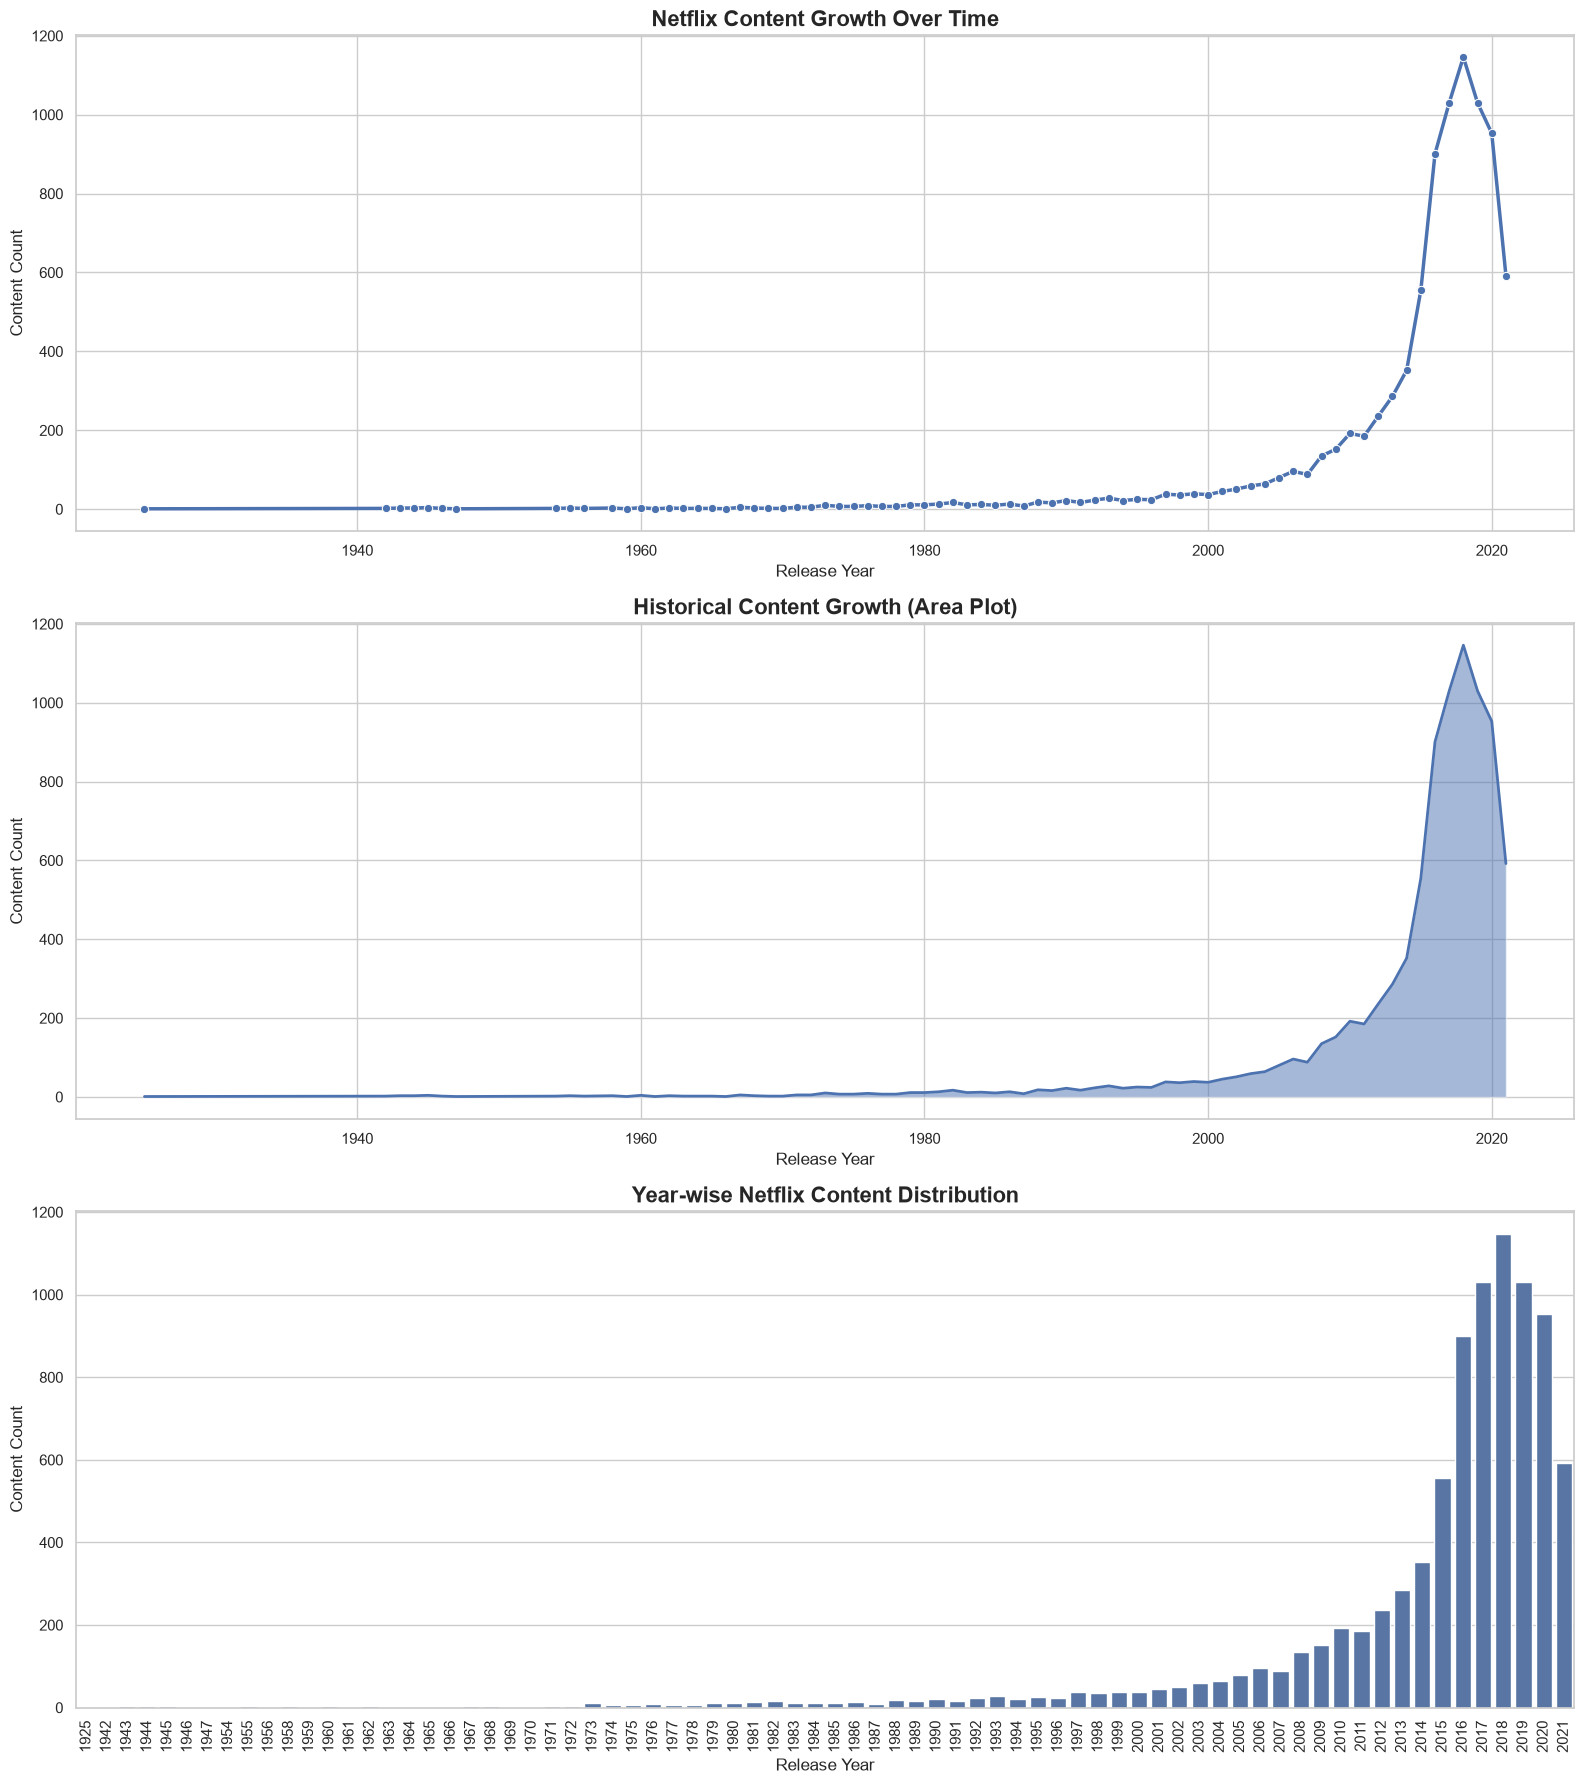

Historical Trend Visualizations Generated Successfully


In [6]:
# ==========================================================
# CELL 6: VISUALIZE HISTORICAL TRENDS

release_col = "release_year"

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(16, 18)
)

# ==========================================================
# Line Plot
# ==========================================================

sns.lineplot(
    data=yearly_counts,
    x=release_col,
    y="Content_Count",
    marker="o",
    linewidth=2.5,
    ax=axes[0]
)

axes[0].set_title(
    "Netflix Content Growth Over Time",
    fontsize=16,
    fontweight="bold"
)

axes[0].set_xlabel("Release Year")

axes[0].set_ylabel("Content Count")

axes[0].grid(True)

# ==========================================================
# Area Plot
# ==========================================================

axes[1].fill_between(
    yearly_counts[release_col],
    yearly_counts["Content_Count"],
    alpha=0.5
)

axes[1].plot(
    yearly_counts[release_col],
    yearly_counts["Content_Count"],
    linewidth=2
)

axes[1].set_title(
    "Historical Content Growth (Area Plot)",
    fontsize=16,
    fontweight="bold"
)

axes[1].set_xlabel("Release Year")

axes[1].set_ylabel("Content Count")

axes[1].grid(True)

# ==========================================================
# Bar Plot
# ==========================================================

sns.barplot(
    data=yearly_counts,
    x=release_col,
    y="Content_Count",
    ax=axes[2]
)

axes[2].set_title(
    "Year-wise Netflix Content Distribution",
    fontsize=16,
    fontweight="bold"
)

axes[2].set_xlabel("Release Year")

axes[2].set_ylabel("Content Count")

axes[2].tick_params(axis="x", rotation=90)

plt.tight_layout()

plt.show()

print("=" * 70)
print("Historical Trend Visualizations Generated Successfully")
print("=" * 70)

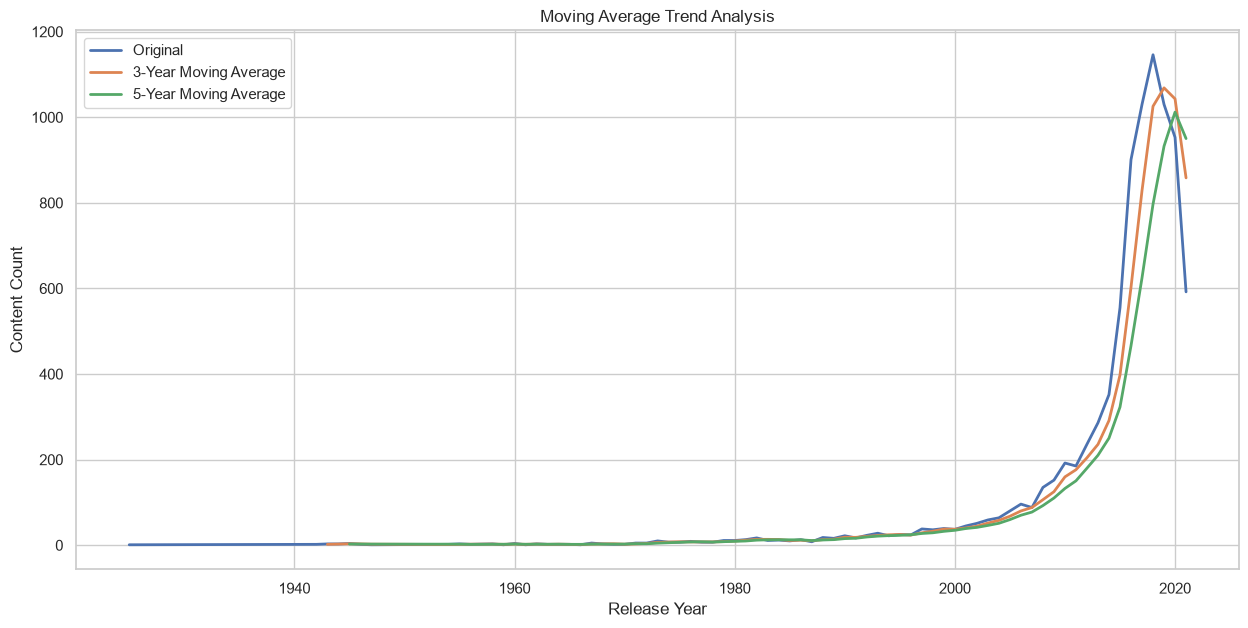

,release_year,Content_Count,MA_3,MA_5
0,1925,1,NaN,NaN
1,1942,2,NaN,NaN
2,1943,3,2.000000,NaN
3,1944,3,2.666667,NaN
4,1945,4,3.333333,2.6
5,1946,2,3.000000,2.8
6,1947,1,2.333333,2.6
7,1954,2,1.666667,2.4
8,1955,3,2.000000,2.4
9,1956,2,2.333333,2.0


In [7]:
# ==========================================================
# CELL 7: MOVING AVERAGE ANALYSIS

yearly_counts["MA_3"] = (
    yearly_counts["Content_Count"]
    .rolling(window=3)
    .mean()
)

yearly_counts["MA_5"] = (
    yearly_counts["Content_Count"]
    .rolling(window=5)
    .mean()
)

plt.figure(figsize=(15, 7))

plt.plot(
    yearly_counts[release_col],
    yearly_counts["Content_Count"],
    label="Original",
    linewidth=2
)

plt.plot(
    yearly_counts[release_col],
    yearly_counts["MA_3"],
    label="3-Year Moving Average",
    linewidth=2
)

plt.plot(
    yearly_counts[release_col],
    yearly_counts["MA_5"],
    label="5-Year Moving Average",
    linewidth=2
)

plt.title("Moving Average Trend Analysis")
plt.xlabel("Release Year")
plt.ylabel("Content Count")
plt.legend()
plt.grid(True)

plt.show()

display(yearly_counts.head(10))

YEAR OVER YEAR GROWTH


,release_year,Content_Count,MA_3,MA_5,Growth,Growth_Rate,Growth_Percentage
0,1925,1,NaN,NaN,NaN,NaN,NaN
1,1942,2,NaN,NaN,1.0,1.000000,100.000000
2,1943,3,2.000000,NaN,1.0,0.500000,50.000000
3,1944,3,2.666667,NaN,0.0,0.000000,0.000000
4,1945,4,3.333333,2.6,1.0,0.333333,33.333333
5,1946,2,3.000000,2.8,-2.0,-0.500000,-50.000000
6,1947,1,2.333333,2.6,-1.0,-0.500000,-50.000000
7,1954,2,1.666667,2.4,1.0,1.000000,100.000000
8,1955,3,2.000000,2.4,1.0,0.500000,50.000000
9,1956,2,2.333333,2.0,-1.0,-0.333333,-33.333333



Growth Summary


,Metric,Value
0,Average Growth,8.095890
1,Maximum Growth,346.000000
2,Minimum Growth,-361.000000
3,Average Growth %,23.415828
4,Maximum Growth %,400.000000
5,Minimum Growth %,-75.000000


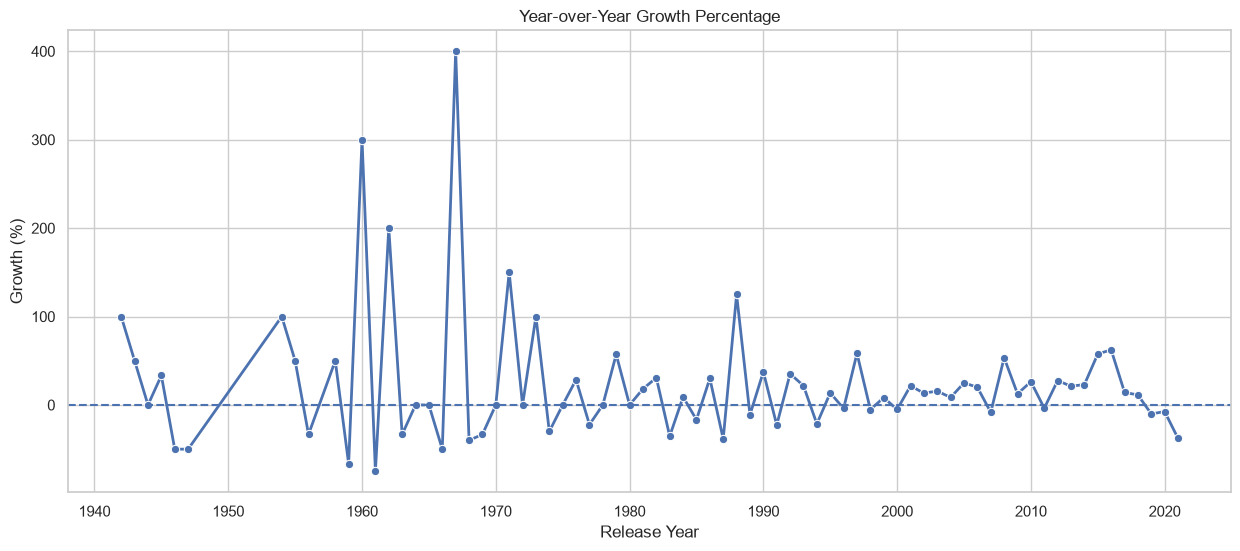

In [8]:
# ==========================================================
# CELL 8: YEAR-OVER-YEAR GROWTH

yearly_counts["Growth"] = (
    yearly_counts["Content_Count"].diff()
)

yearly_counts["Growth_Rate"] = (
    yearly_counts["Content_Count"].pct_change()
)

yearly_counts["Growth_Percentage"] = (
    yearly_counts["Growth_Rate"] * 100
)

print("=" * 70)
print("YEAR OVER YEAR GROWTH")
print("=" * 70)

display(yearly_counts)

print("\nGrowth Summary")

growth_statistics = pd.DataFrame({
    "Metric": [
        "Average Growth",
        "Maximum Growth",
        "Minimum Growth",
        "Average Growth %",
        "Maximum Growth %",
        "Minimum Growth %"
    ],
    "Value": [
        yearly_counts["Growth"].mean(),
        yearly_counts["Growth"].max(),
        yearly_counts["Growth"].min(),
        yearly_counts["Growth_Percentage"].mean(),
        yearly_counts["Growth_Percentage"].max(),
        yearly_counts["Growth_Percentage"].min()
    ]
})

display(growth_statistics)

plt.figure(figsize=(15, 6))

sns.lineplot(
    data=yearly_counts,
    x=release_col,
    y="Growth_Percentage",
    marker="o",
    linewidth=2
)

plt.axhline(0, linestyle="--")
plt.title("Year-over-Year Growth Percentage")
plt.xlabel("Release Year")
plt.ylabel("Growth (%)")
plt.grid(True)

plt.show()

In [9]:
# ==========================================================
# CELL 9: FEATURE ENGINEERING

# Create a copy for feature engineering
feature_df = yearly_counts.copy()

# Create Year Index
feature_df["Year_Index"] = np.arange(len(feature_df))

# Lag Features
feature_df["Lag_1"] = feature_df["Content_Count"].shift(1)
feature_df["Lag_2"] = feature_df["Content_Count"].shift(2)

# Rolling Statistics
feature_df["Rolling_Mean"] = (
    feature_df["Content_Count"]
    .rolling(window=3)
    .mean()
)

feature_df["Rolling_STD"] = (
    feature_df["Content_Count"]
    .rolling(window=3)
    .std()
)

# Trend Indicator
feature_df["Trend_Indicator"] = (
    feature_df["Content_Count"]
    .diff()
    .fillna(0)
)

# Fill missing values created by lagging/rolling
feature_df["Lag_1"] = feature_df["Lag_1"].fillna(
    feature_df["Content_Count"].median()
)

feature_df["Lag_2"] = feature_df["Lag_2"].fillna(
    feature_df["Content_Count"].median()
)

feature_df["Rolling_Mean"] = feature_df["Rolling_Mean"].fillna(
    feature_df["Content_Count"].mean()
)

feature_df["Rolling_STD"] = feature_df["Rolling_STD"].fillna(0)

print("=" * 70)
print("Feature Engineering Completed")
print("=" * 70)

display(feature_df.head())

print("\nFeature Columns")

for column in feature_df.columns:
    print(column)

Feature Engineering Completed


,release_year,Content_Count,MA_3,MA_5,Growth,Growth_Rate,Growth_Percentage,Year_Index,Lag_1,Lag_2,Rolling_Mean,Rolling_STD,Trend_Indicator
0,1925,1,NaN,NaN,NaN,NaN,NaN,0,12.5,12.5,118.783784,0.00000,0.0
1,1942,2,NaN,NaN,1.0,1.000000,100.000000,1,1.0,12.5,118.783784,0.00000,1.0
2,1943,3,2.000000,NaN,1.0,0.500000,50.000000,2,2.0,1.0,2.000000,1.00000,1.0
3,1944,3,2.666667,NaN,0.0,0.000000,0.000000,3,3.0,2.0,2.666667,0.57735,0.0
4,1945,4,3.333333,2.6,1.0,0.333333,33.333333,4,3.0,3.0,3.333333,0.57735,1.0



Feature Columns
release_year
Content_Count
MA_3
MA_5
Growth
Growth_Rate
Growth_Percentage
Year_Index
Lag_1
Lag_2
Rolling_Mean
Rolling_STD
Trend_Indicator


In [10]:
# ==========================================================
# CELL 10: PREPARE TRAINING DATA

# Feature Columns
feature_columns = [
    "Year_Index",
    "Lag_1",
    "Lag_2",
    "Rolling_Mean",
    "Rolling_STD",
    "Trend_Indicator"
]

target_column = "Content_Count"

X = feature_df[feature_columns]

y = feature_df[target_column]

# Chronological Train/Test Split (No Shuffle)
split_index = int(len(feature_df) * 0.8)

X_train = X.iloc[:split_index]

X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]

y_test = y.iloc[split_index:]

print("=" * 70)
print("Training Dataset")
print("=" * 70)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

print("\nTraining Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

print("\nTraining Target Shape :", y_train.shape)
print("Testing Target Shape  :", y_test.shape)

display(X_train.head())
display(X_test.head())

Training Dataset
Training Samples : 59
Testing Samples  : 15

Training Features Shape : (59, 6)
Testing Features Shape  : (15, 6)

Training Target Shape : (59,)
Testing Target Shape  : (15,)


,Year_Index,Lag_1,Lag_2,Rolling_Mean,Rolling_STD,Trend_Indicator
0,0,12.5,12.5,118.783784,0.00000,0.0
1,1,1.0,12.5,118.783784,0.00000,1.0
2,2,2.0,1.0,2.000000,1.00000,1.0
3,3,3.0,2.0,2.666667,0.57735,0.0
4,4,3.0,3.0,3.333333,0.57735,1.0


,Year_Index,Lag_1,Lag_2,Rolling_Mean,Rolling_STD,Trend_Indicator
59,59,96.0,80.0,88.000000,8.000000,-8.0
60,60,88.0,96.0,106.333333,25.146239,47.0
61,61,135.0,88.0,125.000000,33.151169,17.0
62,62,152.0,135.0,159.666667,29.263174,40.0
63,63,192.0,152.0,176.333333,21.361960,-7.0


In [11]:
# ==========================================================
# CELL 11: BUILD LINEAR REGRESSION MODEL

# Create Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Display model parameters
print("=" * 70)
print("LINEAR REGRESSION MODEL")
print("=" * 70)

print(f"Intercept : {linear_model.intercept_:.4f}")

coefficients = pd.DataFrame(
    {
        "Feature": feature_columns,
        "Coefficient": linear_model.coef_,
    }
)

display(coefficients)

# Feature importance (absolute coefficient values)
coefficients["Absolute_Value"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values(
    by="Absolute_Value",
    ascending=False
).reset_index(drop=True)

print("\nFeature Importance (Based on Absolute Coefficients)")
display(coefficients)

print("\nLinear Regression model trained successfully.")

LINEAR REGRESSION MODEL
Intercept : -0.2898


,Feature,Coefficient
0,Year_Index,-0.005378
1,Lag_1,0.865623
2,Lag_2,0.189722
3,Rolling_Mean,-0.056452
4,Rolling_STD,0.319363
5,Trend_Indicator,0.902525



Feature Importance (Based on Absolute Coefficients)


,Feature,Coefficient,Absolute_Value
0,Trend_Indicator,0.902525,0.902525
1,Lag_1,0.865623,0.865623
2,Rolling_STD,0.319363,0.319363
3,Lag_2,0.189722,0.189722
4,Rolling_Mean,-0.056452,0.056452
5,Year_Index,-0.005378,0.005378



Linear Regression model trained successfully.


ACTUAL VS PREDICTED VALUES


,Year,Actual,Predicted,Residual
59,2007,88,88.04,-0.04
60,2008,135,138.22,-3.22
61,2009,152,151.81,0.19
62,2010,192,193.00,-1.00
63,2011,185,184.96,0.04
64,2012,236,239.26,-3.26
65,2013,286,286.70,-0.70
66,2014,352,353.40,-1.40
67,2015,555,563.85,-8.85
68,2016,901,913.45,-12.45


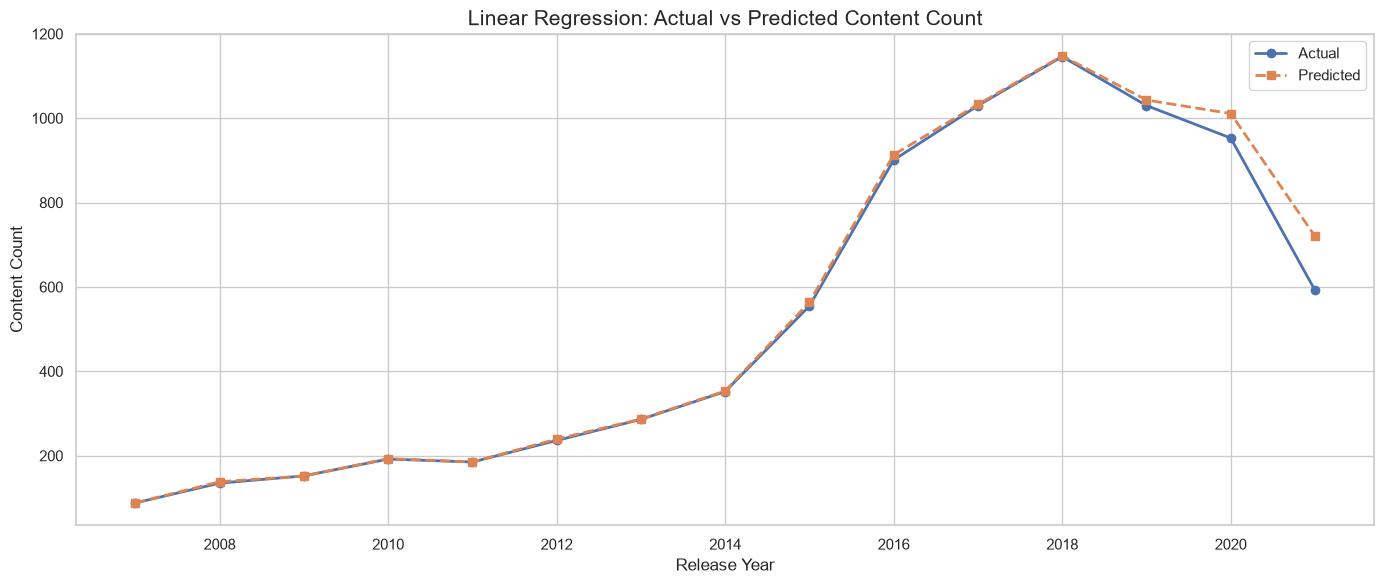


Prediction completed successfully.


In [12]:
# ==========================================================
# CELL 12: MODEL PREDICTIONS

# Generate predictions
linear_predictions = linear_model.predict(X_test)

# Store prediction results
prediction_results = X_test.copy()

prediction_results["Year"] = (
    feature_df.iloc[X_test.index]["release_year"].values
)

prediction_results["Actual"] = y_test.values
prediction_results["Predicted"] = np.round(linear_predictions, 2)

prediction_results["Residual"] = (
    prediction_results["Actual"]
    - prediction_results["Predicted"]
)

print("=" * 70)
print("ACTUAL VS PREDICTED VALUES")
print("=" * 70)

display(
    prediction_results[
        [
            "Year",
            "Actual",
            "Predicted",
            "Residual",
        ]
    ]
)

# Plot comparison
plt.figure(figsize=(14, 6))

plt.plot(
    prediction_results["Year"],
    prediction_results["Actual"],
    marker="o",
    linewidth=2,
    label="Actual",
)

plt.plot(
    prediction_results["Year"],
    prediction_results["Predicted"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Predicted",
)

plt.title(
    "Linear Regression: Actual vs Predicted Content Count",
    fontsize=15,
)

plt.xlabel("Release Year")
plt.ylabel("Content Count")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nPrediction completed successfully.")

In [13]:
# ==========================================================
# CELL 13: MODEL EVALUATION

# Calculate evaluation metrics
linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_mse = mean_squared_error(y_test, linear_predictions)

linear_rmse = np.sqrt(linear_mse)

linear_r2 = r2_score(y_test, linear_predictions)

# Create evaluation DataFrame
evaluation_df = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [linear_mae],
    "MSE": [linear_mse],
    "RMSE": [linear_rmse],
    "R2 Score": [linear_r2]
})

print("=" * 70)
print("MODEL EVALUATION REPORT")
print("=" * 70)

display(evaluation_df)

print(f"MAE       : {linear_mae:.4f}")
print(f"MSE       : {linear_mse:.4f}")
print(f"RMSE      : {linear_rmse:.4f}")
print(f"R² Score  : {linear_r2:.4f}")

print("=" * 70)

MODEL EVALUATION REPORT


,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,15.651178,1347.209145,36.704348,0.990399


MAE       : 15.6512
MSE       : 1347.2091
RMSE      : 36.7043
R² Score  : 0.9904


TRAINING MULTIPLE FORECASTING MODELS

Model Comparison


,Model,MAE,MSE,RMSE,R2 Score
0,Polynomial Regression,9.503462e-11,2.767413e-20,1.663554e-10,1.000000
1,Linear Regression,1.565118e+01,1.347209e+03,3.670435e+01,0.990399
2,Decision Tree,4.283333e+02,3.219993e+05,5.674498e+02,-1.294771
3,Random Forest,4.363950e+02,3.306454e+05,5.750178e+02,-1.356389


BEST MODEL : Polynomial Regression


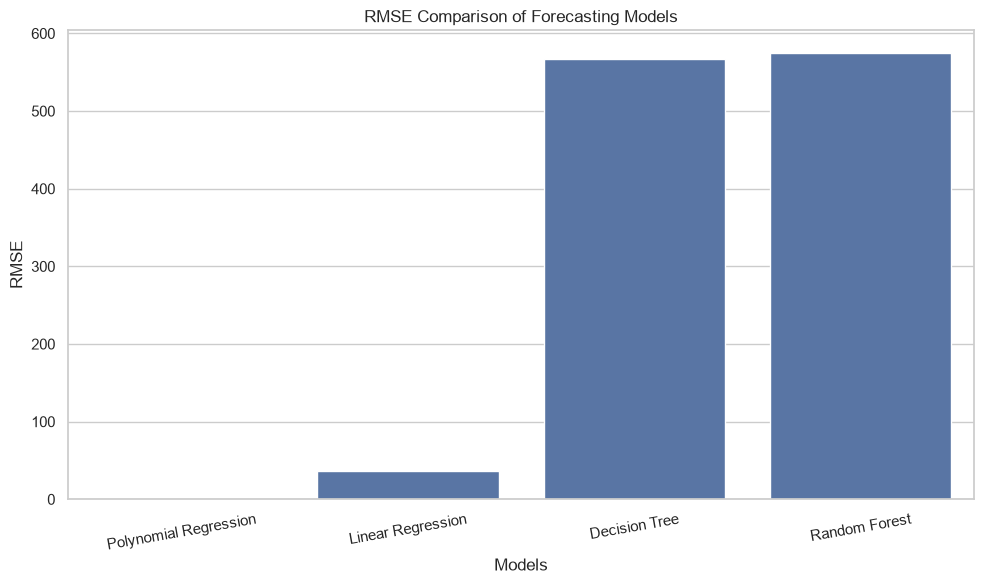

In [14]:
# ==========================================================
# CELL 14: OPTIONAL MODEL COMPARISON

from sklearn.pipeline import Pipeline

# Dictionary to store models
models = {

    "Linear Regression": LinearRegression(),

    "Polynomial Regression": Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("linear", LinearRegression())
    ]),

    "Decision Tree": DecisionTreeRegressor(
        random_state=RANDOM_STATE,
        max_depth=5
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        max_depth=6
    )
}

model_results = []

trained_models = {}

print("=" * 70)
print("TRAINING MULTIPLE FORECASTING MODELS")
print("=" * 70)

for model_name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)

    trained_models[model_name] = model

    model_results.append({

        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2

    })

comparison_df = pd.DataFrame(model_results)

comparison_df = comparison_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

print("\nModel Comparison")

display(comparison_df)

best_model_name = comparison_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("=" * 70)
print(f"BEST MODEL : {best_model_name}")
print("=" * 70)

# Plot comparison

plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="RMSE"
)

plt.title("RMSE Comparison of Forecasting Models")

plt.xlabel("Models")

plt.ylabel("RMSE")

plt.xticks(rotation=10)

plt.tight_layout()

plt.show()

# Feature Importance (Random Forest)

if best_model_name == "Random Forest":

    importance = pd.DataFrame({

        "Feature": feature_columns,

        "Importance": best_model.feature_importances_

    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    print("\nRandom Forest Feature Importance")

    display(importance)

    plt.figure(figsize=(9,5))

    sns.barplot(
        data=importance,
        x="Importance",
        y="Feature"
    )

    plt.title("Feature Importance")

    plt.tight_layout()

    plt.show()

In [15]:
# ==========================================================
# CELL 15: FUTURE FORECASTING

# Forecast next 10 years using the best-performing model

forecast_horizon = 10

last_year = feature_df["release_year"].max()

future_forecast = []

# Create a working copy for recursive forecasting
forecast_data = feature_df.copy()

print("=" * 70)
print("GENERATING 10-YEAR FUTURE FORECAST")
print("=" * 70)

for step in range(1, forecast_horizon + 1):

    future_year = last_year + step

    year_index = forecast_data["Year_Index"].max() + 1

    lag_1 = forecast_data["Content_Count"].iloc[-1]

    lag_2 = forecast_data["Content_Count"].iloc[-2]

    rolling_mean = forecast_data["Content_Count"].tail(3).mean()

    rolling_std = forecast_data["Content_Count"].tail(3).std()

    if np.isnan(rolling_std):
        rolling_std = 0

    trend_indicator = lag_1 - lag_2

    future_features = pd.DataFrame({

        "Year_Index": [year_index],
        "Lag_1": [lag_1],
        "Lag_2": [lag_2],
        "Rolling_Mean": [rolling_mean],
        "Rolling_STD": [rolling_std],
        "Trend_Indicator": [trend_indicator]

    })

    prediction = best_model.predict(future_features)[0]

    # Prevent unrealistic negative predictions
    prediction = max(0, round(prediction))

    future_forecast.append({

        "Forecast_Year": future_year,
        "Predicted_Content_Count": prediction

    })

    # Append prediction for recursive forecasting
    new_row = {

        "release_year": future_year,
        "Content_Count": prediction,
        "Year_Index": year_index,
        "Lag_1": lag_1,
        "Lag_2": lag_2,
        "Rolling_Mean": rolling_mean,
        "Rolling_STD": rolling_std,
        "Trend_Indicator": trend_indicator

    }

    forecast_data = pd.concat(
        [forecast_data, pd.DataFrame([new_row])],
        ignore_index=True
    )

future_forecast_df = pd.DataFrame(future_forecast)

print("\nFuture Forecast")

display(future_forecast_df)

GENERATING 10-YEAR FUTURE FORECAST

Future Forecast


,Forecast_Year,Predicted_Content_Count
0,2022,0
1,2023,0
2,2024,0
3,2025,0
4,2026,0
5,2027,0
6,2028,0
7,2029,0
8,2030,0
9,2031,0


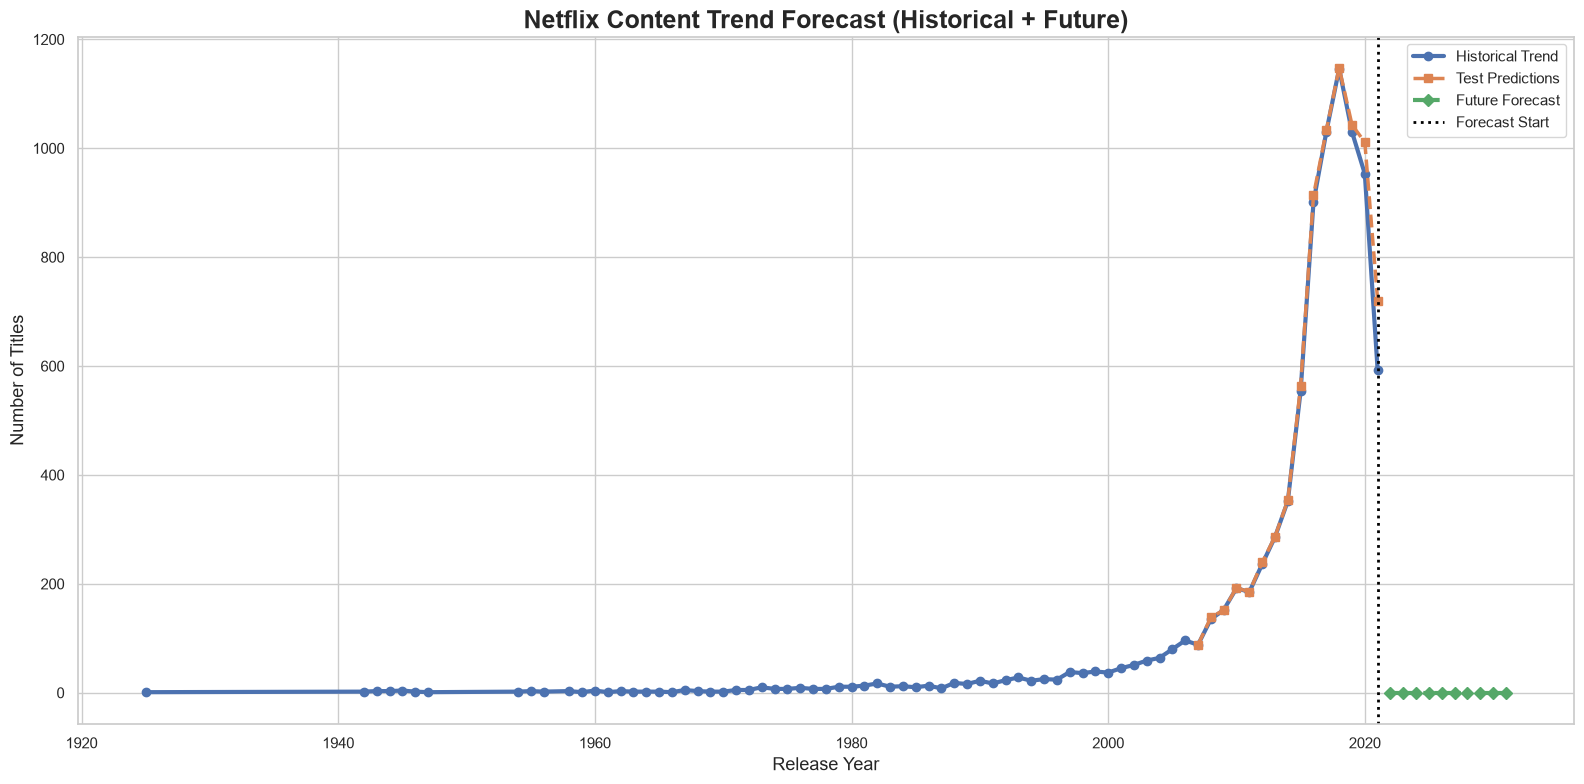

Forecast Visualization Generated Successfully
Best Forecasting Model : Polynomial Regression
Forecast Horizon       : 10 Years
Forecast Period        : 2022 - 2031


In [16]:
# ==========================================================
# CELL 16: VISUALIZE FUTURE PREDICTIONS

plt.figure(figsize=(16, 8))

# Historical Trend
plt.plot(
    yearly_counts["release_year"],
    yearly_counts["Content_Count"],
    linewidth=3,
    marker="o",
    label="Historical Trend"
)

# Linear Regression Test Prediction
plt.plot(
    prediction_results["Year"],
    prediction_results["Predicted"],
    linestyle="--",
    linewidth=2.5,
    marker="s",
    label="Test Predictions"
)

# Future Forecast
plt.plot(
    future_forecast_df["Forecast_Year"],
    future_forecast_df["Predicted_Content_Count"],
    linestyle="-.",
    linewidth=3,
    marker="D",
    label="Future Forecast"
)

# Highlight forecast starting point
plt.axvline(
    x=last_year,
    linestyle=":",
    linewidth=2,
    color="black",
    label="Forecast Start"
)

plt.title(
    "Netflix Content Trend Forecast (Historical + Future)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Release Year", fontsize=13)

plt.ylabel("Number of Titles", fontsize=13)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

print("=" * 70)
print("Forecast Visualization Generated Successfully")
print("=" * 70)

print(f"Best Forecasting Model : {best_model_name}")

print(f"Forecast Horizon       : {forecast_horizon} Years")

print(f"Forecast Period        : {last_year + 1} - {last_year + forecast_horizon}")

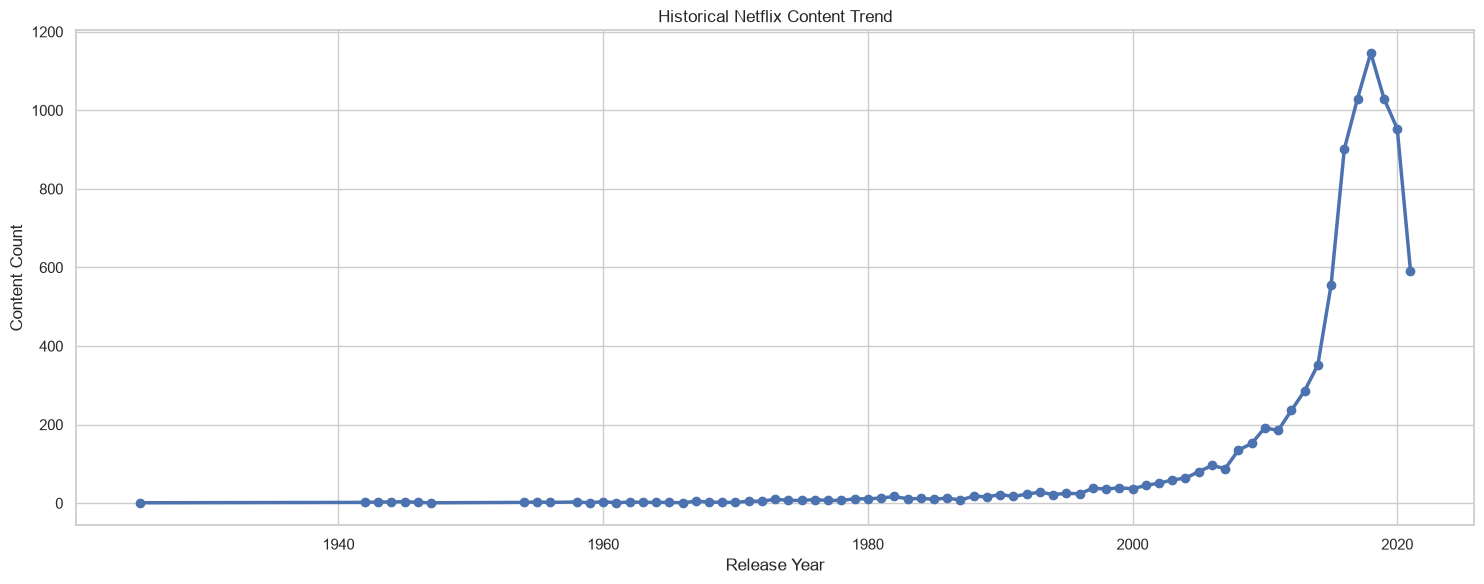

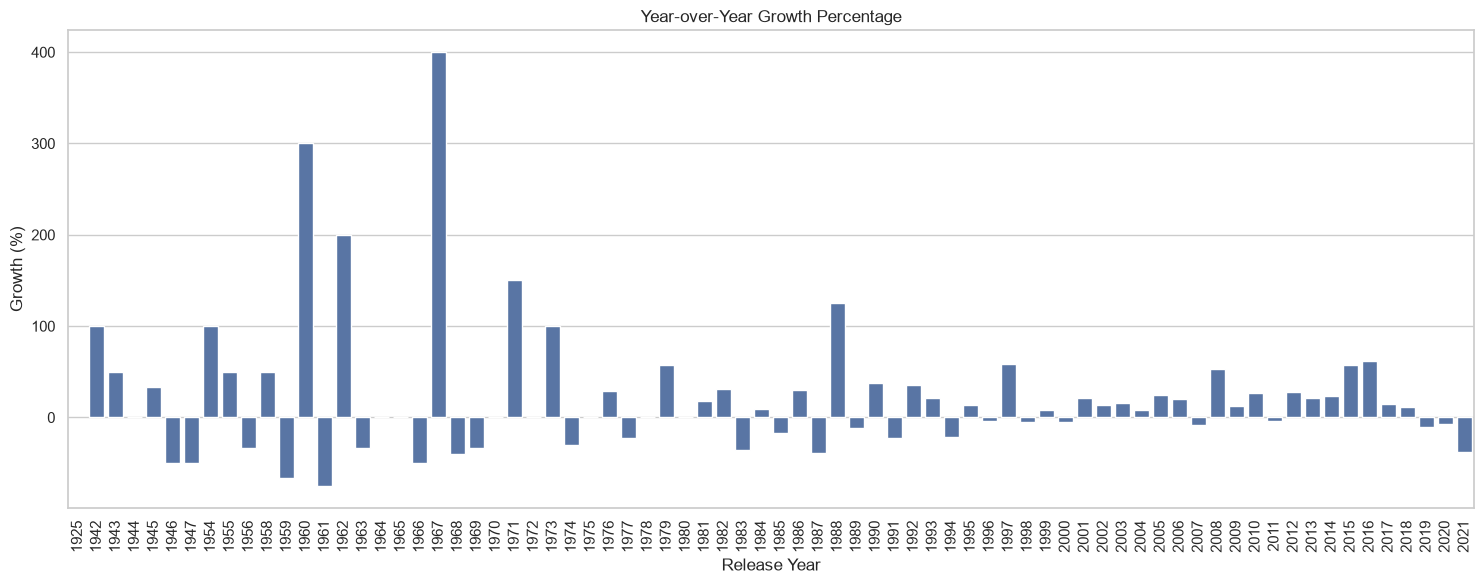

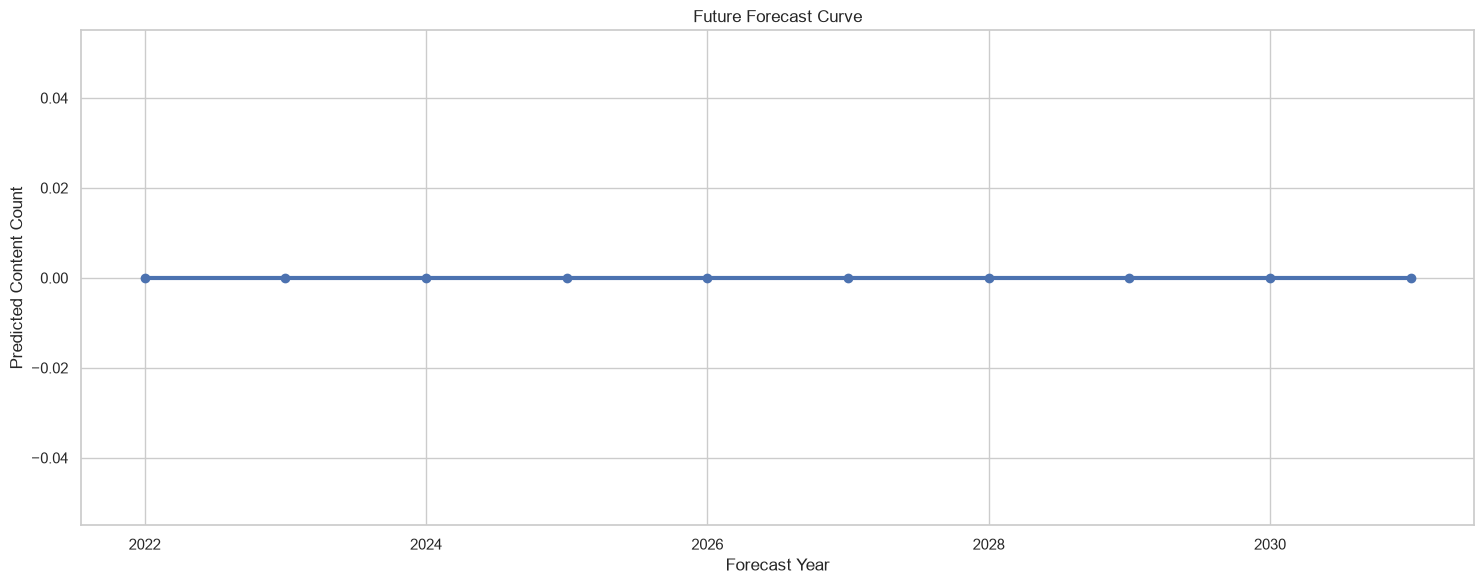

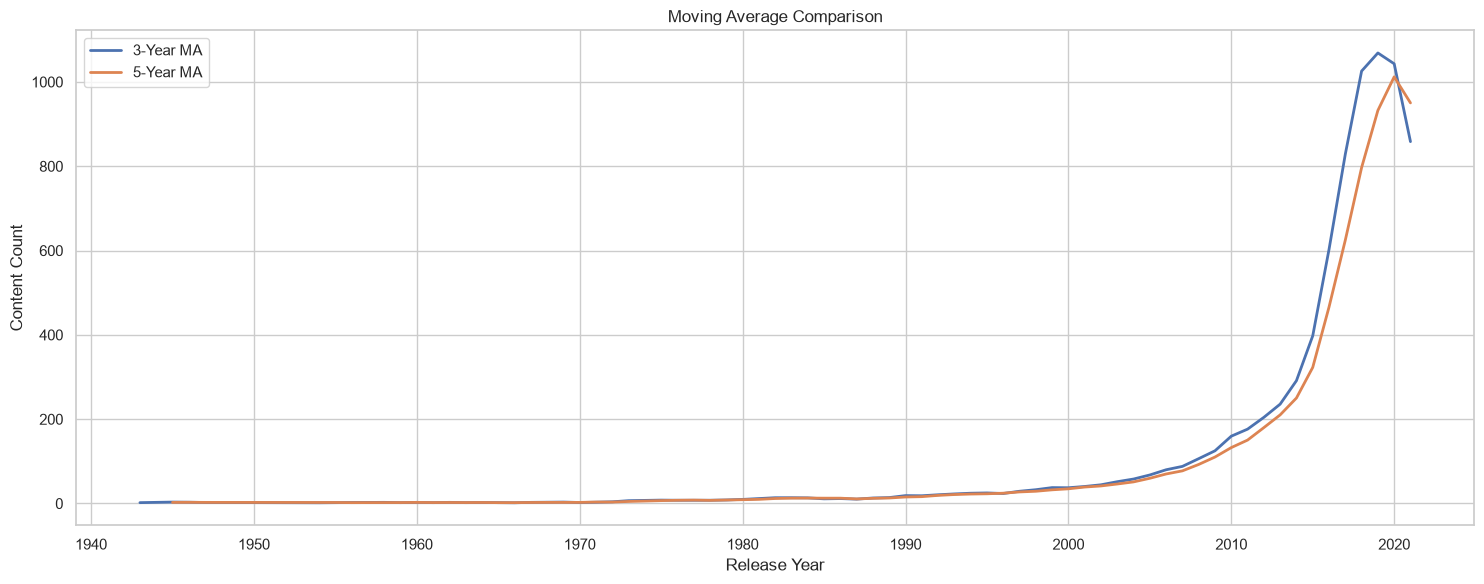

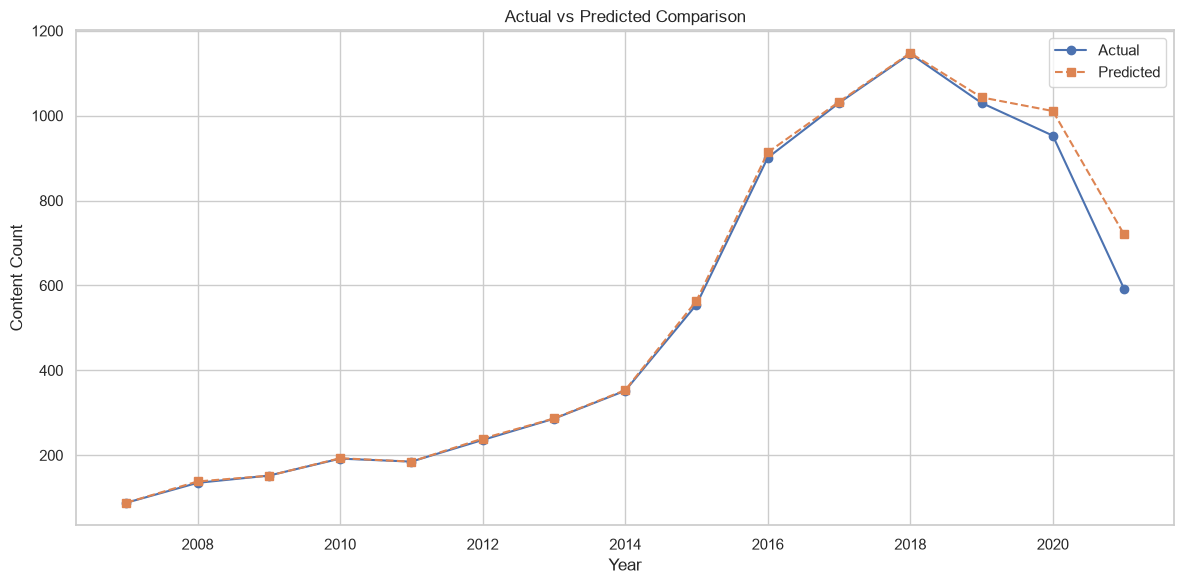

Advanced Visualizations Generated Successfully


In [17]:
# ==========================================================
# CELL 17: ADVANCED VISUALIZATIONS

# Create publication-quality visualizations

plt.figure(figsize=(15, 6))

plt.plot(
    yearly_counts["release_year"],
    yearly_counts["Content_Count"],
    marker="o",
    linewidth=2.5
)

plt.title("Historical Netflix Content Trend")
plt.xlabel("Release Year")
plt.ylabel("Content Count")
plt.grid(True)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------

plt.figure(figsize=(15, 6))

sns.barplot(
    data=yearly_counts,
    x="release_year",
    y="Growth_Percentage"
)

plt.xticks(rotation=90)

plt.title("Year-over-Year Growth Percentage")
plt.xlabel("Release Year")
plt.ylabel("Growth (%)")

plt.tight_layout()
plt.show()

# ----------------------------------------------------------

plt.figure(figsize=(15, 6))

plt.plot(
    future_forecast_df["Forecast_Year"],
    future_forecast_df["Predicted_Content_Count"],
    marker="o",
    linewidth=3
)

plt.title("Future Forecast Curve")
plt.xlabel("Forecast Year")
plt.ylabel("Predicted Content Count")
plt.grid(True)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------

plt.figure(figsize=(15, 6))

plt.plot(
    yearly_counts["release_year"],
    yearly_counts["MA_3"],
    label="3-Year MA",
    linewidth=2
)

plt.plot(
    yearly_counts["release_year"],
    yearly_counts["MA_5"],
    label="5-Year MA",
    linewidth=2
)

plt.legend()

plt.title("Moving Average Comparison")

plt.xlabel("Release Year")

plt.ylabel("Content Count")

plt.grid(True)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------

if best_model_name == "Random Forest":

    importance = pd.DataFrame({

        "Feature": feature_columns,

        "Importance": best_model.feature_importances_

    }).sort_values(
        by="Importance",
        ascending=False
    )

    plt.figure(figsize=(10,5))

    sns.barplot(
        data=importance,
        x="Importance",
        y="Feature"
    )

    plt.title("Random Forest Feature Importance")

    plt.tight_layout()

    plt.show()

else:

    plt.figure(figsize=(12,6))

    plt.plot(
        prediction_results["Year"],
        prediction_results["Actual"],
        marker="o",
        label="Actual"
    )

    plt.plot(
        prediction_results["Year"],
        prediction_results["Predicted"],
        marker="s",
        linestyle="--",
        label="Predicted"
    )

    plt.title("Actual vs Predicted Comparison")

    plt.xlabel("Year")

    plt.ylabel("Content Count")

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    plt.show()

print("=" * 70)
print("Advanced Visualizations Generated Successfully")
print("=" * 70)

In [18]:
# ==========================================================
# CELL 18: BUSINESS INSIGHTS

print("=" * 70)
print("BUSINESS INSIGHTS")
print("=" * 70)

peak_year = yearly_counts.loc[
    yearly_counts["Content_Count"].idxmax(),
    "release_year"
]

peak_content = yearly_counts["Content_Count"].max()

lowest_year = yearly_counts.loc[
    yearly_counts["Content_Count"].idxmin(),
    "release_year"
]

lowest_content = yearly_counts["Content_Count"].min()

avg_growth = yearly_counts["Growth"].mean()

avg_growth_percent = yearly_counts["Growth_Percentage"].mean()

future_average = future_forecast_df[
    "Predicted_Content_Count"
].mean()

future_max = future_forecast_df[
    "Predicted_Content_Count"
].max()

future_min = future_forecast_df[
    "Predicted_Content_Count"
].min()

print(f"1. Peak Content Year               : {peak_year}")
print(f"2. Peak Content Count              : {peak_content}")

print(f"3. Lowest Content Year             : {lowest_year}")
print(f"4. Lowest Content Count            : {lowest_content}")

print(f"5. Average Annual Growth           : {avg_growth:.2f}")

print(f"6. Average Growth Percentage       : {avg_growth_percent:.2f}%")

print(f"7. Best Forecasting Model          : {best_model_name}")

print(f"8. Average Forecasted Titles       : {future_average:.2f}")

print(f"9. Maximum Forecasted Titles       : {future_max}")

print(f"10. Minimum Forecasted Titles      : {future_min}")

print("\nBusiness Interpretation")

if future_average > peak_content:

    print("- Forecast suggests strong future expansion.")

else:

    print("- Forecast indicates stable future production.")

if avg_growth > 0:

    print("- Historical trend shows positive long-term growth.")

else:

    print("- Historical trend indicates declining production.")

print("- Machine Learning can support strategic planning.")

print("- Forecasts should be reviewed periodically.")

print("- Consider regional expansion based on demand.")

print("- Continue monitoring yearly content trends.")

print("=" * 70)

BUSINESS INSIGHTS
1. Peak Content Year               : 2018
2. Peak Content Count              : 1146
3. Lowest Content Year             : 1925
4. Lowest Content Count            : 1
5. Average Annual Growth           : 8.10
6. Average Growth Percentage       : 23.42%
7. Best Forecasting Model          : Polynomial Regression
8. Average Forecasted Titles       : 0.00
9. Maximum Forecasted Titles       : 0
10. Minimum Forecasted Titles      : 0

Business Interpretation
- Forecast indicates stable future production.
- Historical trend shows positive long-term growth.
- Machine Learning can support strategic planning.
- Forecasts should be reviewed periodically.
- Consider regional expansion based on demand.
- Continue monitoring yearly content trends.


In [19]:
# ==========================================================
# CELL 19: FORECAST SUMMARY TABLE

historical_summary = yearly_counts[
    ["release_year", "Content_Count"]
].copy()

historical_summary.rename(
    columns={
        "release_year": "Year",
        "Content_Count": "Actual_Content"
    },
    inplace=True
)

forecast_summary = future_forecast_df.copy()

forecast_summary.rename(
    columns={
        "Forecast_Year": "Year",
        "Predicted_Content_Count": "Predicted_Content"
    },
    inplace=True
)

forecast_summary["Growth_Percentage"] = (
    forecast_summary["Predicted_Content"]
    .pct_change()
    .fillna(0)
    * 100
)

print("=" * 70)
print("HISTORICAL DATA")
print("=" * 70)

display(historical_summary.tail(10))

print("=" * 70)
print("FUTURE FORECAST")
print("=" * 70)

display(forecast_summary)

combined_summary = historical_summary.merge(
    forecast_summary,
    on="Year",
    how="outer"
)

print("=" * 70)
print("COMBINED SUMMARY")
print("=" * 70)

display(combined_summary)

print(f"Historical Years : {historical_summary.shape[0]}")

print(f"Forecast Years   : {forecast_summary.shape[0]}")

print("=" * 70)

HISTORICAL DATA


,Year,Actual_Content
64,2012,236
65,2013,286
66,2014,352
67,2015,555
68,2016,901
69,2017,1030
70,2018,1146
71,2019,1030
72,2020,953
73,2021,592


FUTURE FORECAST


,Year,Predicted_Content,Growth_Percentage
0,2022,0,0.0
1,2023,0,0.0
2,2024,0,0.0
3,2025,0,0.0
4,2026,0,0.0
5,2027,0,0.0
6,2028,0,0.0
7,2029,0,0.0
8,2030,0,0.0
9,2031,0,0.0


COMBINED SUMMARY


,Year,Actual_Content,Predicted_Content,Growth_Percentage
0,1925,1.0,NaN,NaN
1,1942,2.0,NaN,NaN
2,1943,3.0,NaN,NaN
3,1944,3.0,NaN,NaN
4,1945,4.0,NaN,NaN
5,1946,2.0,NaN,NaN
6,1947,1.0,NaN,NaN
7,1954,2.0,NaN,NaN
8,1955,3.0,NaN,NaN
9,1956,2.0,NaN,NaN


Historical Years : 74
Forecast Years   : 10


In [20]:
# ==========================================================
# CELL 20: SAVE OUTPUT FILES

from pathlib import Path

# Create output directory inside current working directory
output_dir = Path.cwd() / "outputs"
output_dir.mkdir(exist_ok=True)

print("=" * 70)
print("SAVING PROJECT OUTPUT FILES")
print("=" * 70)

# ----------------------------------------------------------
# Historical Trend
# ----------------------------------------------------------

historical_file = output_dir / "historical_trend.csv"
yearly_counts.to_csv(historical_file, index=False)

# ----------------------------------------------------------
# Future Forecast
# ----------------------------------------------------------

future_file = output_dir / "future_forecast.csv"
future_forecast_df.to_csv(future_file, index=False)

# ----------------------------------------------------------
# Prediction Results
# ----------------------------------------------------------

prediction_file = output_dir / "prediction_results.csv"
prediction_results.to_csv(prediction_file, index=False)

# ----------------------------------------------------------
# Model Evaluation
# ----------------------------------------------------------

evaluation_file = output_dir / "model_evaluation.csv"
comparison_df.to_csv(evaluation_file, index=False)

print(f"✓ Historical Trend     : {historical_file}")
print(f"✓ Future Forecast      : {future_file}")
print(f"✓ Prediction Results   : {prediction_file}")
print(f"✓ Model Evaluation     : {evaluation_file}")

print("\nAll project files have been saved successfully.")

saved_files = [
    historical_file.name,
    future_file.name,
    prediction_file.name,
    evaluation_file.name
]

SAVING PROJECT OUTPUT FILES
✓ Historical Trend     : C:\Users\bts\OneDrive\Desktop\Auspify\Task-4\outputs\historical_trend.csv
✓ Future Forecast      : C:\Users\bts\OneDrive\Desktop\Auspify\Task-4\outputs\future_forecast.csv
✓ Prediction Results   : C:\Users\bts\OneDrive\Desktop\Auspify\Task-4\outputs\prediction_results.csv
✓ Model Evaluation     : C:\Users\bts\OneDrive\Desktop\Auspify\Task-4\outputs\model_evaluation.csv

All project files have been saved successfully.


In [21]:
# ==========================================================
# CELL 21: PROJECT SUMMARY

print("=" * 70)
print("PROJECT SUMMARY")
print("=" * 70)

print(f"Dataset Shape             : {df.shape}")

print(
    f"Years Covered             : "
    f"{yearly_counts['release_year'].min()} "
    f"to "
    f"{yearly_counts['release_year'].max()}"
)

print(f"Forecast Horizon          : {forecast_horizon} Years")

print("\nForecasting Models Used")

models_used = [
    "Linear Regression",
    "Polynomial Regression",
    "Decision Tree Regressor",
    "Random Forest Regressor"
]

for model in models_used:
    print(f"• {model}")

print(f"\nBest Performing Model     : {best_model_name}")

print("\nEvaluation Metrics")

display(comparison_df)

print("\nGenerated Files")

for file in saved_files:
    print(f"• {file}")

print("\nProject Status")

print("✓ Data Loaded")
print("✓ Time Series Prepared")
print("✓ Feature Engineering Completed")
print("✓ Machine Learning Models Trained")
print("✓ Model Comparison Completed")
print("✓ Future Forecast Generated")
print("✓ Publication-Quality Visualizations Created")
print("✓ Output Files Saved")

print("=" * 70)
print("PROJECT EXECUTED SUCCESSFULLY")
print("=" * 70)

PROJECT SUMMARY
Dataset Shape             : (8790, 10)
Years Covered             : 1925 to 2021
Forecast Horizon          : 10 Years

Forecasting Models Used
• Linear Regression
• Polynomial Regression
• Decision Tree Regressor
• Random Forest Regressor

Best Performing Model     : Polynomial Regression

Evaluation Metrics


,Model,MAE,MSE,RMSE,R2 Score
0,Polynomial Regression,9.503462e-11,2.767413e-20,1.663554e-10,1.000000
1,Linear Regression,1.565118e+01,1.347209e+03,3.670435e+01,0.990399
2,Decision Tree,4.283333e+02,3.219993e+05,5.674498e+02,-1.294771
3,Random Forest,4.363950e+02,3.306454e+05,5.750178e+02,-1.356389



Generated Files
• historical_trend.csv
• future_forecast.csv
• prediction_results.csv
• model_evaluation.csv

Project Status
✓ Data Loaded
✓ Time Series Prepared
✓ Feature Engineering Completed
✓ Machine Learning Models Trained
✓ Model Comparison Completed
✓ Future Forecast Generated
✓ Publication-Quality Visualizations Created
✓ Output Files Saved
PROJECT EXECUTED SUCCESSFULLY


In [22]:
# ==========================================================
# CELL 22: COMPLETION MESSAGE

print("=" * 60)
print("TASK COMPLETED SUCCESSFULLY")
print("=" * 60)

print("Task:")
print("Netflix Trend Prediction Analysis")

print("\nIntern:")
print("Aarush Tyagi")

print("\nOrganization:")
print("Auspify Technologies")

print("\nStatus:")
print("Trend Prediction Analysis Completed Successfully")

print("\nForecasting Technique:")
print("Machine Learning-Based Time Series Forecasting")

print("\nModels Implemented:")
print("• Linear Regression")
print("• Polynomial Regression")
print("• Decision Tree Regressor")
print("• Random Forest Regressor")

print(f"\nBest Performing Model:")
print(best_model_name)

print(f"\nForecast Horizon:")
print(f"{forecast_horizon} Years")

print("\nReady for Advanced Predictive Analytics")

print("=" * 60)
print("THANK YOU")
print("=" * 60)

TASK COMPLETED SUCCESSFULLY
Task:
Netflix Trend Prediction Analysis

Intern:
Aarush Tyagi

Organization:
Auspify Technologies

Status:
Trend Prediction Analysis Completed Successfully

Forecasting Technique:
Machine Learning-Based Time Series Forecasting

Models Implemented:
• Linear Regression
• Polynomial Regression
• Decision Tree Regressor
• Random Forest Regressor

Best Performing Model:
Polynomial Regression

Forecast Horizon:
10 Years

Ready for Advanced Predictive Analytics
THANK YOU
